In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from matplotlib.lines import Line2D
from pyprojroot import here

In [2]:
RAW_DATA_DIR = here() / "data" / "raw"
INTERIM_DATA_DIR = here() / "data" / "interim"
PROCESSED_DATA_DIR = here() / "data" / "processed"
RESULTS_DATA_DIR = here() / "results"

In [3]:
shp = gpd.read_file(RAW_DATA_DIR/'geography/municipalities/00mun.shp')
df_lisa = pd.read_csv(RESULTS_DATA_DIR/"esda/LISA_RELMS.csv")
ent = gpd.read_file(RAW_DATA_DIR/'geography/federal_states/00ent.shp')
shp['CVEGEO'] = shp['CVEGEO'].astype(str).str.zfill(5)

In [4]:
df_lisa['CVEGEO'] = df_lisa['CVEGEO'].astype(str).str.zfill(5)

In [5]:
gdf_lisa = shp.merge(df_lisa, on='CVEGEO', how='left')
gdf_lisa['cluster'] = gdf_lisa['cluster'].fillna('ns')

In [6]:
colors = {
    'HH': '#DC143C',  
    'HL': '#FF474C', 
    'LH': '#000080',   
    'LL': '#4169E1', 
    'ns': '#c7c6c1' 
}

In [7]:
ciit_lat, ciit_lon = 17.3000, -94.9900

ciit_gdf = gpd.GeoDataFrame(
    {"name": ["CIIT / Helax H₂ Plant"]},
    geometry=gpd.points_from_xy([ciit_lon], [ciit_lat]),
    crs="EPSG:4326"
).to_crs("EPSG:6372")

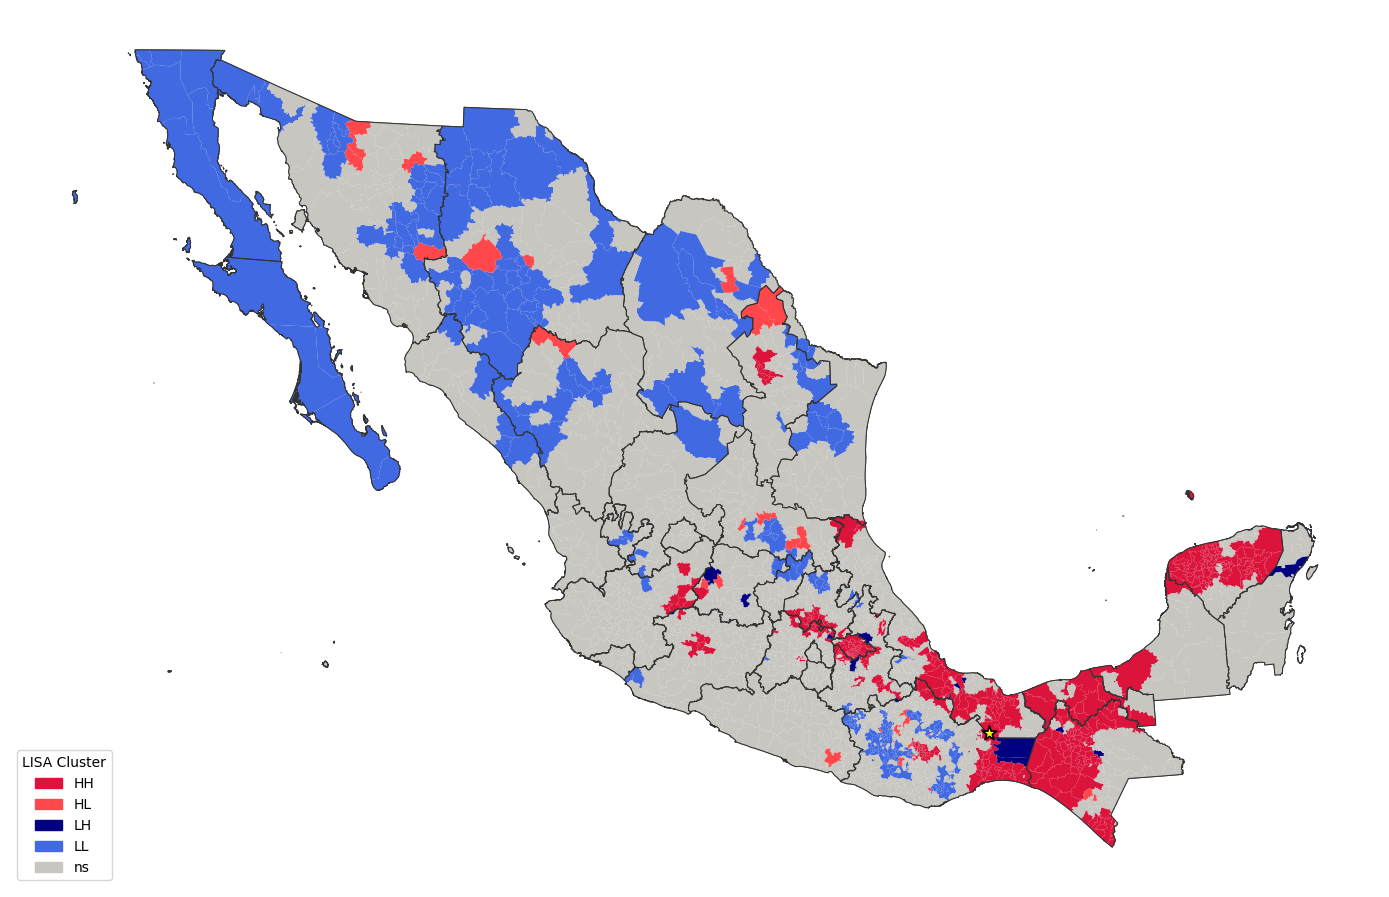

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(14, 10))


gdf_lisa['color'] = gdf_lisa['cluster'].map(colors)

ent.plot(ax=ax, color='#f5f5f5', edgecolor='#333333', linewidth=0.7)

gdf_lisa.plot(ax=ax, color=gdf_lisa['color'], edgecolor='none', linewidth=0.7)

ent.plot(ax=ax, color='none', edgecolor='#333333', linewidth=0.7)

ciit_gdf.plot(
    ax=ax,
    color="yellow",
    markersize=120,
    marker="*",
    edgecolor="black",
    linewidth=1.2,
    zorder=10
)

patches = [mpatches.Patch(color=c, label=l) for l, c in colors.items()]
ax.legend(handles=patches, title='LISA Cluster', loc='lower left', frameon=True)

#ax.set_title('LISA Cluster Map — R.E.L.M.S. Index', fontsize=14, fontweight='bold')
ax.set_axis_off()

plt.tight_layout()
plt.savefig(RESULTS_DATA_DIR/'maps/LISA_RELMS_map.png', dpi=300, bbox_inches='tight')
plt.show()